# 12_SES_Computation

Computes the **Skill Extinction Score (SES)** for every skill.

### Formula
```
SES = 0.40 × Feature Intelligence
    + 0.35 × Forecast Intelligence
    + 0.25 × Cluster Intelligence
```

### Tiers
| SES Range | Tier |
|---|---|
| 0.80 – 1.00 | Very Safe |
| 0.60 – 0.79 | Safe |
| 0.40 – 0.59 | Moderate |
| 0.20 – 0.39 | Risky |
| 0.00 – 0.19 | Extinction Risk |

### Outputs
- `ses_rankings.csv`


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ── load inputs ──────────────────────────────────────────────────────────────
skills    = pd.read_csv('../Generated Datasets/expanded_skill_master.csv')
forecasts = pd.read_csv('../Generated Datasets/forecast_results.csv')
v9        = pd.read_csv('../Generated Datasets/master_skill_dataset_v9.csv')

# normalise join key
for df in [skills, forecasts, v9]:
    df['skill'] = df['skill'].str.lower().str.strip()

print("Skills   :", skills.shape)
print("Forecasts:", forecasts.shape)
print("V9       :", v9.shape)


Skills   : (114, 9)
Forecasts: (114, 12)
V9       : (116, 19)


In [13]:
# ── build master frame ───────────────────────────────────────────────────────
# Start from skills (ground truth skill list)
df = skills.copy()

# bring in cluster / archetype from v9
cluster_cols = ['skill', 'cluster', 'archetype', 'pc1', 'pc2']
v9_sub = v9[[c for c in cluster_cols if c in v9.columns]].drop_duplicates('skill')
df = df.merge(v9_sub, on='skill', how='left')

# bring in forecast scores
fc_cols = ['skill', 'forecast_method', 'confidence',
           'forecast_1y', 'forecast_2y', 'forecast_3y',
           'forecast_score', 'forecast_trend', 'history_length']
fc_sub = forecasts[[c for c in fc_cols if c in forecasts.columns]].drop_duplicates('skill')
df = df.merge(fc_sub, on='skill', how='left')

print("Master frame:", df.shape)
print("Columns:", df.columns.tolist())


Master frame: (114, 21)
Columns: ['skill', 'sub_category', 'linkedin_demand', 'salary_premium', 'current_usage', 'future_interest', 'global_adoption_score', 'growth_rate', 'history_found', 'cluster', 'archetype', 'pc1', 'pc2', 'forecast_method', 'confidence', 'forecast_1y', 'forecast_2y', 'forecast_3y', 'forecast_score', 'forecast_trend', 'history_length']


In [14]:
# ── 1. FEATURE INTELLIGENCE SCORE (0-1) ─────────────────────────────────────
# Weighted composite of the six workforce intelligence features
FEATURE_WEIGHTS = {
    'linkedin_demand'      : 0.25,
    'salary_premium'       : 0.20,
    'current_usage'        : 0.20,
    'future_interest'      : 0.20,
    'global_adoption_score': 0.10,
    'growth_rate'          : 0.05,
}

# Normalise each feature to [0, 1] (some columns may already be normalised)
scaler = MinMaxScaler()
for col in FEATURE_WEIGHTS:
    if col in df.columns:
        df[col] = scaler.fit_transform(df[[col]].fillna(0))

df['feature_score'] = sum(
    w * df[col].fillna(0)
    for col, w in FEATURE_WEIGHTS.items()
    if col in df.columns
)

print("Feature score stats:")
print(df['feature_score'].describe().round(4))


Feature score stats:
count    114.0000
mean       0.3231
std        0.0880
min        0.1685
25%        0.2691
50%        0.3074
75%        0.3596
max        0.6270
Name: feature_score, dtype: float64


In [15]:
# ── 2. FORECAST INTELLIGENCE SCORE (0-1) ─────────────────────────────────────
# Use the composite forecast_score from notebook 10.
# If missing, impute with feature_score (worst-case fallback).
df['forecast_score'] = df['forecast_score'].fillna(df['feature_score'])

# Confidence penalty: lower confidence → shrink toward 0.5 neutral
df['confidence'] = df['confidence'].fillna(0.35)
df['forecast_intelligence'] = (
    df['confidence'] * df['forecast_score'] +
    (1 - df['confidence']) * 0.50
)

print("Forecast intelligence stats:")
print(df['forecast_intelligence'].describe().round(4))


Forecast intelligence stats:
count    114.0000
mean       0.2080
std        0.1449
min        0.0873
25%        0.1233
50%        0.1477
75%        0.2203
max        0.9250
Name: forecast_intelligence, dtype: float64


In [16]:
# ── 3. CLUSTER INTELLIGENCE SCORE (0-1) ──────────────────────────────────────
# Map archetype → survival score
ARCHETYPE_SCORES = {
    'Future-Proof': 0.90,
    'Growing'     : 0.70,
    'Stable'      : 0.50,
    'High-Risk'   : 0.30,
}

df['cluster_score'] = df['archetype'].map(ARCHETYPE_SCORES)

# For skills without a cluster assignment, fall back to feature score
df['cluster_score'] = df['cluster_score'].fillna(df['feature_score'] * 0.8)

print("Cluster score stats:")
print(df['cluster_score'].describe().round(4))
print("\nArchetype distribution:")
print(df['archetype'].value_counts())


Cluster score stats:
count    114.0000
mean       0.5445
std        0.2079
min        0.1993
25%        0.3000
50%        0.7000
75%        0.7000
max        0.9000
Name: cluster_score, dtype: float64

Archetype distribution:
archetype
Growing         55
High-Risk       40
Stable           9
Future-Proof     7
Name: count, dtype: int64


In [17]:
# ── 4. FINAL SES ─────────────────────────────────────────────────────────────
W_FEATURE  = 0.40
W_FORECAST = 0.35
W_CLUSTER  = 0.25

df['ses_score'] = (
    W_FEATURE  * df['feature_score'] +
    W_FORECAST * df['forecast_intelligence'] +
    W_CLUSTER  * df['cluster_score']
)

# Clip to [0, 1]
df['ses_score'] = df['ses_score'].clip(0, 1).round(6)

print("SES score stats:")
print(df['ses_score'].describe().round(4))


SES score stats:
count    114.0000
mean       0.3382
std        0.0904
min        0.1934
25%        0.2888
50%        0.3270
75%        0.3577
max        0.7676
Name: ses_score, dtype: float64


In [18]:
# ── 5. TIER ASSIGNMENT ───────────────────────────────────────────────────────
def assign_tier(score):
    if score >= 0.60: return 'Very Safe'
    if score >= 0.30: return 'Safe'
    if score >= 0.20: return 'Moderate'
    if score >= 0.10: return 'Risky'
    return 'Extinction Risk'

df['ses_tier'] = df['ses_score'].apply(assign_tier)

print("Tier distribution:")
print(df['ses_tier'].value_counts())


Tier distribution:
ses_tier
Safe         78
Moderate     32
Very Safe     3
Risky         1
Name: count, dtype: int64


In [19]:
# ── 6. RANK ─────────────────────────────────────────────────────────────────
df = df.sort_values('ses_score', ascending=False).reset_index(drop=True)
df['ses_rank'] = df.index + 1

print("\nTop 20 skills by SES:")
print(df[['ses_rank','skill','ses_score','ses_tier','archetype','forecast_trend']]
      .head(20).to_string(index=False))



Top 20 skills by SES:
 ses_rank                  skill  ses_score  ses_tier    archetype forecast_trend
        1             javascript   0.767596 Very Safe Future-Proof         Stable
        2                 python   0.720562 Very Safe Future-Proof         Stable
        3                    sql   0.684792 Very Safe Future-Proof         Stable
        4             postgresql   0.570765      Safe Future-Proof         Stable
        5                 docker   0.570093      Safe Future-Proof         Stable
        6             typescript   0.548743      Safe Future-Proof         Stable
        7          data analysis   0.519976      Safe Future-Proof         Stable
        8                    aws   0.476512      Safe    High-Risk         Stable
        9                   apis   0.423957      Safe      Growing         Stable
       10                    api   0.414773      Safe      Growing         Stable
       11                  react   0.393296      Safe    High-Risk        G

In [20]:
# ── 7. SAVE ──────────────────────────────────────────────────────────────────
output_cols = [
    'ses_rank', 'skill', 'sub_category',
    'ses_score', 'ses_tier',
    'feature_score', 'forecast_intelligence', 'cluster_score',
    'archetype', 'cluster',
    'linkedin_demand', 'salary_premium', 'current_usage',
    'future_interest', 'global_adoption_score', 'growth_rate',
    'forecast_1y', 'forecast_2y', 'forecast_3y',
    'forecast_method', 'forecast_trend', 'confidence', 'history_length'
]

ses_df = df[[c for c in output_cols if c in df.columns]]
ses_df.to_csv('../Generated Datasets/ses_rankings.csv', index=False)

print(f"Saved → ../Generated Datasets/ses_rankings.csv")
print(f"Shape : {ses_df.shape}")
print("\nTier summary:")
print(ses_df.groupby('ses_tier')['ses_score']
      .agg(['count','mean','min','max'])
      .round(3))


Saved → ../Generated Datasets/ses_rankings.csv
Shape : (114, 23)

Tier summary:
           count   mean    min    max
ses_tier                             
Moderate      32  0.263  0.204  0.298
Risky          1  0.193  0.193  0.193
Safe          78  0.356  0.303  0.571
Very Safe      3  0.724  0.685  0.768


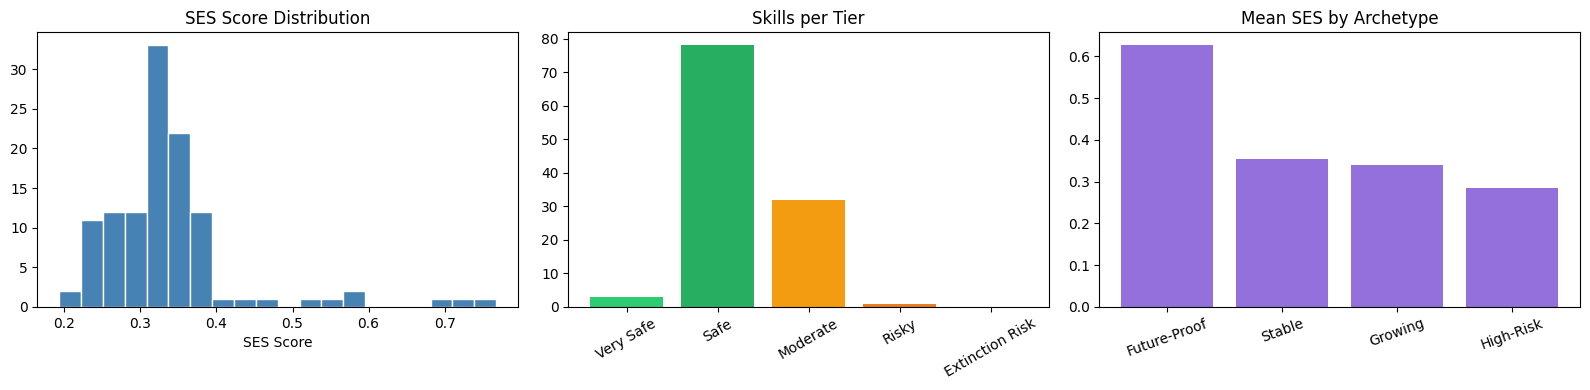

Plot saved.


In [21]:
# ── 8. QUICK VALIDATION ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# SES score histogram
axes[0].hist(ses_df['ses_score'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('SES Score Distribution')
axes[0].set_xlabel('SES Score')

# Tier bar chart
tier_order = ['Very Safe','Safe','Moderate','Risky','Extinction Risk']
tier_counts = ses_df['ses_tier'].value_counts().reindex(tier_order, fill_value=0)
axes[1].bar(tier_counts.index, tier_counts.values,
            color=['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c'])
axes[1].set_title('Skills per Tier')
axes[1].tick_params(axis='x', rotation=30)

# Archetype vs SES
archetype_ses = ses_df.groupby('archetype')['ses_score'].mean().sort_values(ascending=False)
axes[2].bar(archetype_ses.index, archetype_ses.values, color='mediumpurple')
axes[2].set_title('Mean SES by Archetype')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../Generated Datasets/ses_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved.")


In [23]:
df[['skill','ses_score','ses_tier']].head(10)

,skill,ses_score,ses_tier
0,javascript,0.767596,Very Safe
1,python,0.720562,Very Safe
2,sql,0.684792,Very Safe
3,postgresql,0.570765,Safe
4,docker,0.570093,Safe
5,typescript,0.548743,Safe
6,data analysis,0.519976,Safe
7,aws,0.476512,Safe
8,apis,0.423957,Safe
9,api,0.414773,Safe
